In [1]:
import matplotlib.pyplot as plt 
from astropy import units as u
from astropy.io import fits
import numpy as np 
from reproject import reproject_interp
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.visualization import simple_norm

In [2]:
directory = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/S0121+3848/"
cube = "S0116+4114_HIcube2_clean_smooth_image_4_cube.fits"

In [3]:
header = fits.getheader(directory+cube)
data = fits.getdata(directory+cube)
#data moment0
data_mom0 = fits.getdata(directory+"output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9_0mom.fits")
header_mom0 = fits.getheader(directory+"output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9_0mom.fits")
#data moment1
data_mom1 = fits.getdata(directory+"output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9_1mom.fits")
#data moment2
data_mom2 = fits.getdata(directory+"output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9_2mom.fits")
#data model
data_model = fits.getdata(directory+"output/SoFiA_J012118.02+402905.9/SoFiA_J012118.02+402905.9mod_azim.fits")
#moment 0 of the model
data_model_mom0 = fits.getdata(directory+"output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9mod_0mom_azim.fits")
#moment 1 of the model
data_model_mom1 = fits.getdata(directory+"output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9mod_1mom_azim.fits")
#moment 2 of the model
data_model_mom2 = fits.getdata(directory+"output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9mod_2mom_azim.fits")

In [4]:
# upload the optical image 
optical_file = "S0116-4114-sdssg-optical.fits"
header_optical  = fits.getheader(directory+optical_file)
data_optical = fits.getdata(directory+optical_file)

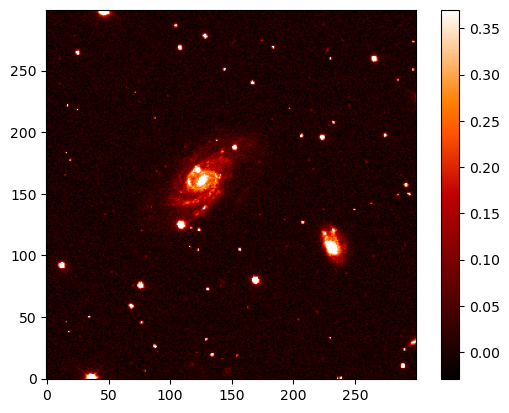

In [5]:
vmin, vmax = np.percentile(data_optical, [1, 99.5])
plt.imshow(data_optical, cmap='gist_heat', vmin=vmin, vmax=vmax, origin='lower')
plt.colorbar()
plt.show()

### Reproject the HI image into the same pixel grid as the optical image

In [7]:
def calc_rms(x):
    rms = np.sqrt(np.nanmean(x**2))
    return rms

In [8]:
hdul_mom0 = fits.open(directory+"output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9_0mom.fits")
hi_reprojected_0,footprint = reproject_interp(hdul_mom0,header_optical)
rms_mom0 = np.sqrt(np.nanmean(hi_reprojected_0**2))

In [9]:
print(rms_mom0)
print(np.nanmax(hi_reprojected_0))

0.6914341888267675
1.247195839881897


In [10]:
np.linspace(2 * rms_mom0, np.nanmax(hi_reprojected_0), 13)

array([1.38286838, 1.37156233, 1.36025629, 1.34895024, 1.3376442 ,
       1.32633815, 1.31503211, 1.30372606, 1.29242002, 1.28111397,
       1.26980793, 1.25850188, 1.24719584])

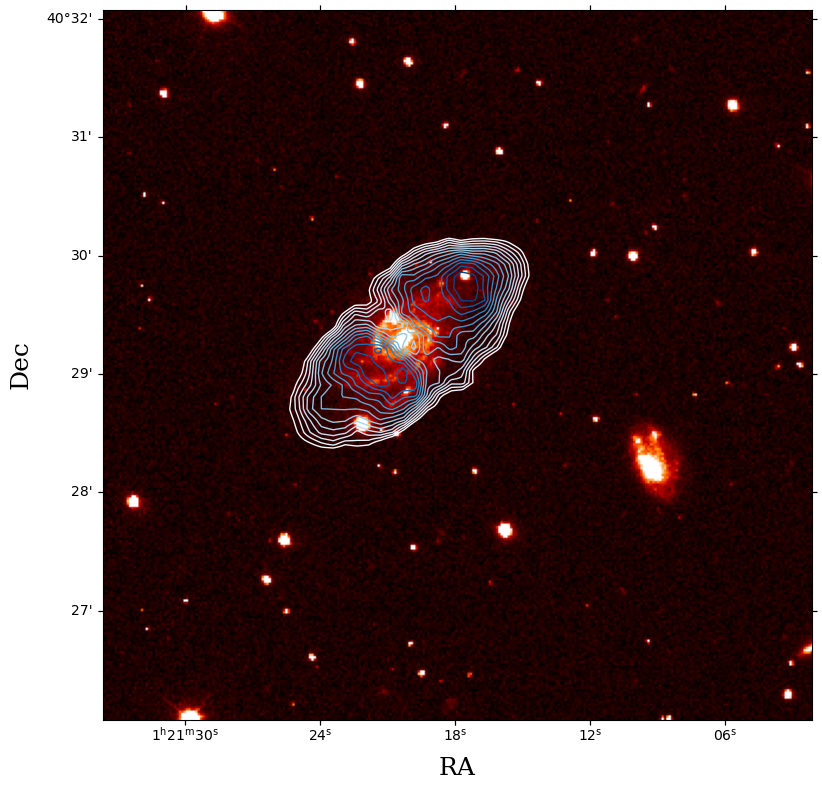

In [11]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(1, 1, 1, projection=WCS(header_optical))

# Background: Optical image
cb = ax.imshow(
    data_optical,
    cmap='gist_heat',  
    origin='lower',
    vmin=vmin, vmax=vmax,
)


levels = np.linspace(1 * rms_mom0, np.nanmax(hi_reprojected_0), 14)
ax.contour(
    hi_reprojected_0,
    levels=levels,
    cmap='Blues', 
    linewidths=1,
)

ax.set_xlabel('RA', size=18, family='serif')
ax.set_ylabel('Dec', size=18, family='serif')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig('ngc7752-mom0-optical.png',dpi=300,bbox_inches='tight')
plt.tight_layout()
plt.show()

In [12]:
# compute the reprojection for moment 1 
hdulmom1 = fits.open(directory+"output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9_1mom.fits")
hi_mom1_rep, foot_mom1=reproject_interp(hdulmom1,header_optical)
rms_mom1=(np.sqrt(np.nanmean(hi_mom1_rep**2)))

In [13]:
print(np.nanmin(hi_mom1_rep),np.nanmax(hi_mom1_rep))
print(rms_mom1)

5616.92822265625 5886.958984375
5748.128217973929


In [14]:
np.linspace(1 * rms_mom1, np.nanmax(hi_mom1_rep), 13)
#np.arange(np.nanmin(hi_mom1_rep),np.nanmax(hi_mom1_rep),10)

array([5748.12821797, 5759.69744851, 5771.26667904, 5782.83590957,
       5794.40514011, 5805.97437064, 5817.54360117, 5829.11283171,
       5840.68206224, 5852.25129277, 5863.82052331, 5875.38975384,
       5886.95898438])

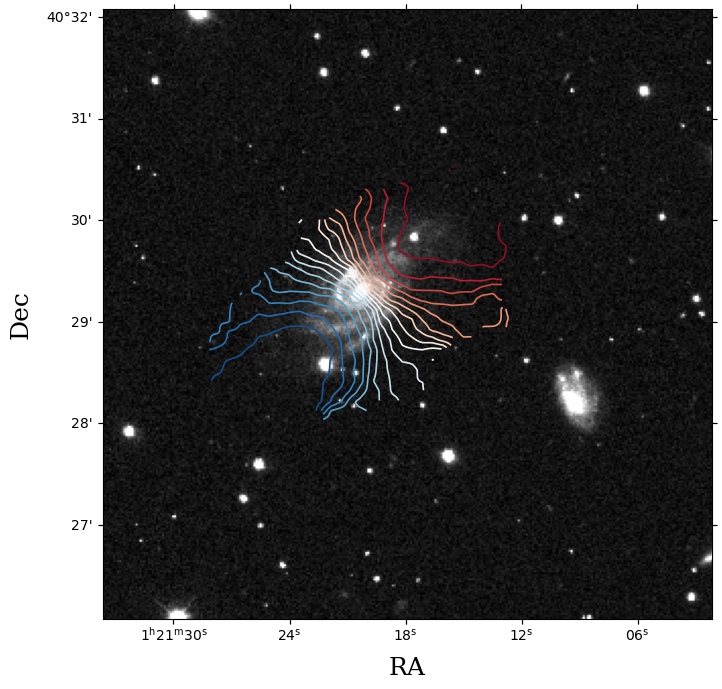

In [15]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(1, 1, 1, projection=WCS(header_optical))

# Use log stretch for better contrast in faint structures
norm = simple_norm(data_optical, 'log', percent=99.5)
ax.imshow(data_optical, cmap='gist_gray', vmin=vmin,vmax=vmax, origin='lower')

# Velocity field (moment 1) contours: reversed RdBu, centered around systemic velocity
# Adjust levels if needed based on your specific velocity range
vel_min, vel_max = np.nanmin(hi_mom1_rep), np.nanmax(hi_mom1_rep)  # You can automate this with np.nanmin/max if desired
levels = np.arange(vel_min, vel_max,15)
#levels = np.linspace(1* rms_mom1, np.nanmax(hi_mom1_rep), 15)
cont = ax.contour(hi_mom1_rep, levels=levels, cmap='RdBu_r', linewidths=1.2)

# Add a colorbar for the moment 1 contours (velocity field)
# label the contour, this is optional
#ax.clabel(cont, inline=True, fmt='%d km/s', fontsize=10)

ax.set_xlabel('RA', size=18, family='serif')
ax.set_ylabel('Dec', size=18, family='serif')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# save figure 
plt.savefig('ngc7752-mom1-optical.png',dpi=300,bbox_inches='tight')
plt.tight_layout()
plt.show()

In [16]:
hdulmom2 = fits.open(directory+"output/SoFiA_J012118.02+402905.9/maps/SoFiA_J012118.02+402905.9_2mom.fits")
hi_mom2_rep, foot_mom2=reproject_interp(hdulmom2,header_optical)
rms_mom2=(np.sqrt(np.nanmean(hi_mom2_rep**2)))

In [17]:
print(rms_mom2)
print(np.nanmin(hi_mom2_rep),np.nanmax(hi_mom2_rep))

28.271071733532743
0.00012205331586301327 63.415103912353516


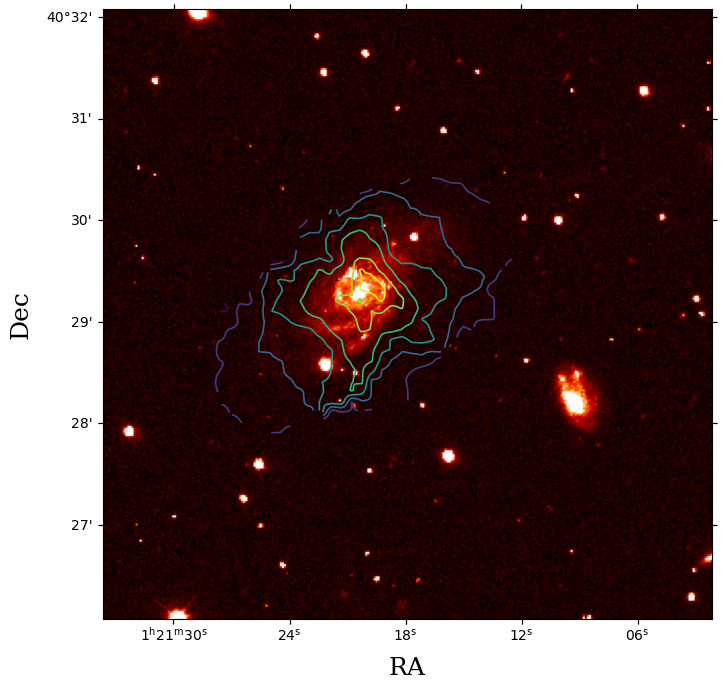

In [18]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(1, 1, 1, projection=WCS(header_optical))

# Improve optical background contrast
norm = simple_norm(data_optical, 'log', percent=99.5)
ax.imshow(data_optical, cmap='gist_heat', vmin=vmin,vmax=vmax, origin='lower')

# Contours for moment 2 (velocity dispersion)
disp_min, disp_max = np.nanmin(hi_mom2_rep),np.nanmax(hi_mom2_rep)  # in km/s (check your units)
levels = np.arange(disp_min, disp_max, 10)
cont = ax.contour(hi_mom2_rep, levels=levels, cmap='viridis', linewidths=1.2)

# Label the contours
#ax.clabel(cont, inline=True, fmt='%d km/s', fontsize=10)

# Axis formatting
ax.set_xlabel('RA', size=18, family='serif')
ax.set_ylabel('Dec', size=18, family='serif')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.savefig('ngc7752-mom2-optical.png',dpi=300,bbox_inches='tight')
plt.tight_layout()
plt.show()

## Residuals

In [19]:
residual_mom0 = data_mom0 -data_model_mom0
residual_mom1 = data_mom1 -data_model_mom1
residual_mom2 = data_mom2 -data_model_mom2

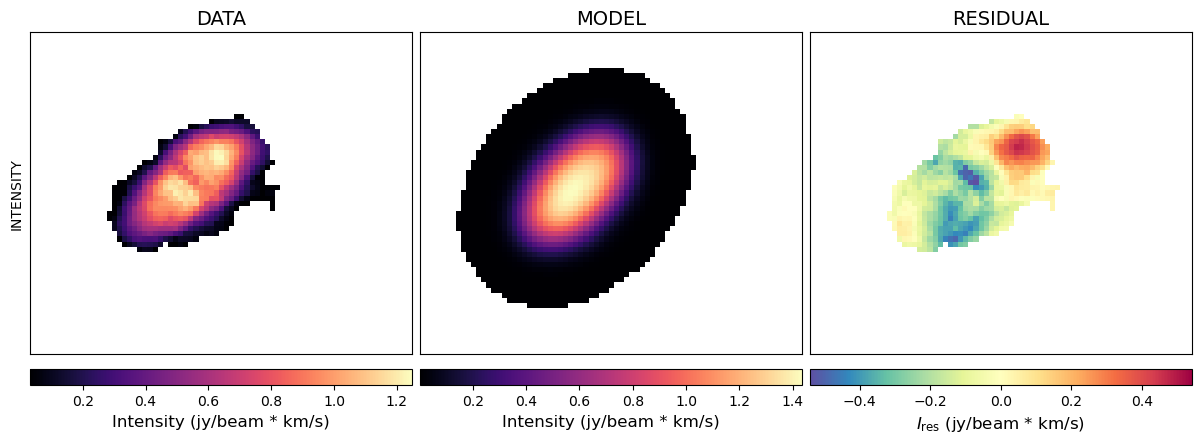

In [20]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create figure and axes
fig, axs = plt.subplots(1, 3, figsize=(15, 5), gridspec_kw={'wspace': 0.02})  # tighter spacing

# Common image kwargs
common_kwargs = dict(origin='lower', interpolation='none')

# ---------- Panel 1: DATA ----------
im1 = axs[0].imshow(data_mom0, cmap='magma', **common_kwargs)
axs[0].set_title('DATA', fontsize=14)
axs[0].set_ylabel('INTENSITY')
axs[0].tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)

# Add shared colorbar below first two panels
divider1 = make_axes_locatable(axs[0])
cax1 = divider1.append_axes("bottom", size="5%", pad=0.15)
cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
cbar1.set_label('Intensity (jy/beam * km/s)', fontsize=12)

# ---------- Panel 2: MODEL ----------
im2 = axs[1].imshow(data_model_mom0, cmap='magma', **common_kwargs)
axs[1].set_title('MODEL', fontsize=14)
axs[1].tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)

# Share colorbar with first panel
divider2 = make_axes_locatable(axs[1])
cax2 = divider2.append_axes("bottom", size="5%", pad=0.15)
cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
cbar2.set_label('Intensity (jy/beam * km/s)', fontsize=12)

# ---------- Panel 3: RESIDUAL ----------
resid_abs_max = np.nanmax(np.abs(residual_mom0))
im3 = axs[2].imshow(residual_mom0, cmap='Spectral_r', vmin=-resid_abs_max, vmax=resid_abs_max, **common_kwargs)
axs[2].set_title('RESIDUAL', fontsize=14)
axs[2].tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)

# Separate colorbar for residuals
divider3 = make_axes_locatable(axs[2])
cax3 = divider3.append_axes("bottom", size="5%", pad=0.15)
cbar3 = plt.colorbar(im3, cax=cax3, orientation='horizontal')   
cbar3.set_label(r'$I_{\mathrm{res}}$ (jy/beam * km/s)', fontsize=12)

# Equal aspect ratio for all panels
for ax in axs:
    ax.set_aspect('equal')

# Optional export
plt.savefig("ngc7752-moment0-residuals.png", dpi=300, bbox_inches='tight')
plt.show()


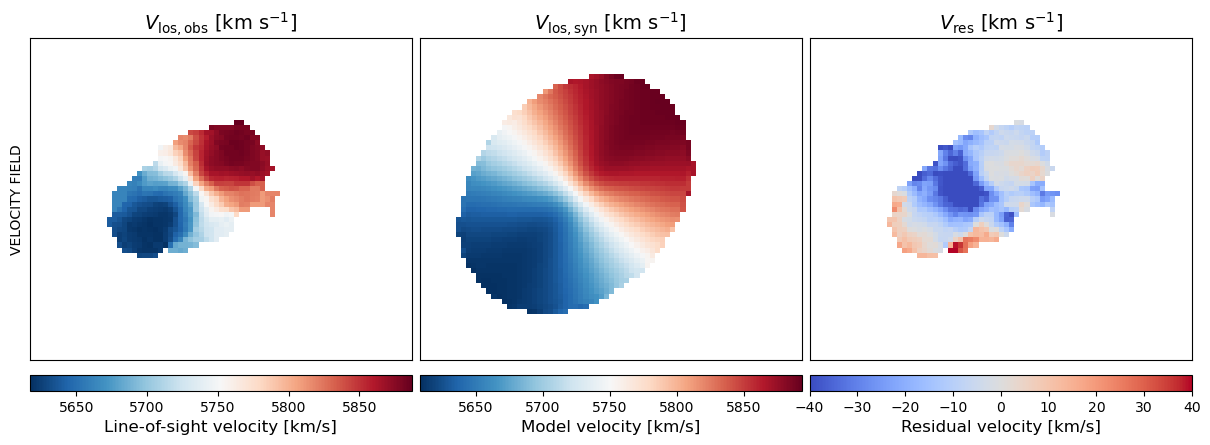

In [21]:
# Create figure and axes
fig, axs = plt.subplots(1, 3, figsize=(15, 5), gridspec_kw={'wspace': 0.02})

# Shared image display settings
common_kwargs = dict(origin='lower', interpolation='none')

# ---------- Panel 1: Observed velocity ----------
im1 = axs[0].imshow(data_mom1, cmap='RdBu_r', **common_kwargs)
axs[0].set_title(r'$V_{\mathrm{los,obs}}$ [km s$^{-1}$]', fontsize=14)
axs[0].set_ylabel('VELOCITY FIELD')
axs[0].tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)

divider1 = make_axes_locatable(axs[0])
cax1 = divider1.append_axes("bottom", size="5%", pad=0.15)
cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
cbar1.set_label('Line-of-sight velocity [km/s]', fontsize=12)

# ---------- Panel 2: Model velocity ----------
im2 = axs[1].imshow(data_model_mom1, cmap='RdBu_r', **common_kwargs)
axs[1].set_title(r'$V_{\mathrm{los,syn}}$ [km s$^{-1}$]', fontsize=14)
axs[1].tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)

divider2 = make_axes_locatable(axs[1])
cax2 = divider2.append_axes("bottom", size="5%", pad=0.15)
cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
cbar2.set_label('Model velocity [km/s]', fontsize=12)

# ---------- Panel 3: Residual velocity ----------
resid_vlim = 40  # km/s
im3 = axs[2].imshow(residual_mom1, cmap='coolwarm', vmin=-resid_vlim, vmax=resid_vlim, **common_kwargs)
axs[2].set_title(r'$V_{\mathrm{res}}$ [km s$^{-1}$]', fontsize=14)
axs[2].tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)

divider3 = make_axes_locatable(axs[2])
cax3 = divider3.append_axes("bottom", size="5%", pad=0.15)
cbar3 = plt.colorbar(im3, cax=cax3, orientation='horizontal')
cbar3.set_label(r'Residual velocity [km/s]', fontsize=12)

# Format all panels
for ax in axs:
    ax.set_aspect('equal')

# Optional: Export as publication-quality PDF
# plt.savefig("moment1_threepanel_velocity.pdf", dpi=300, bbox_inches='tight')
plt.show()

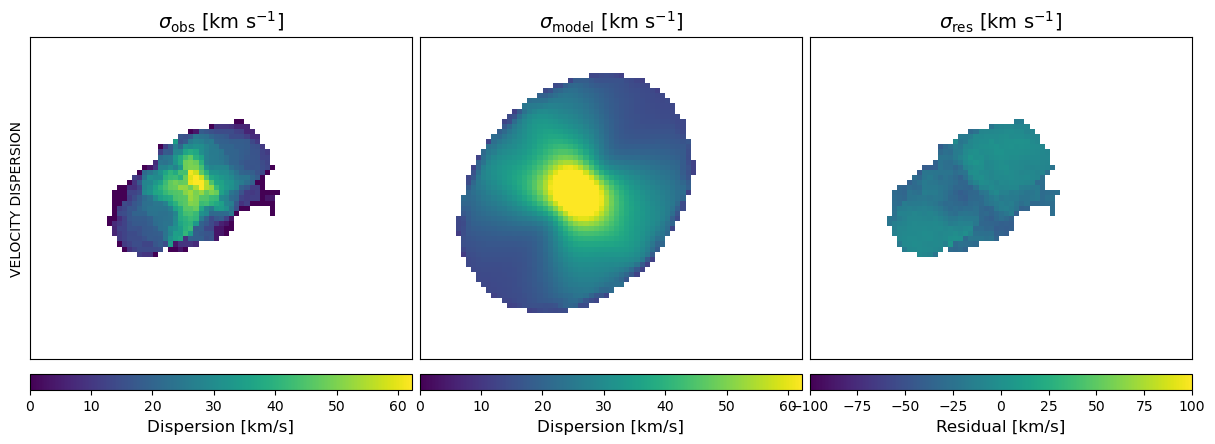

In [22]:
# Create figure and axes with tight spacing
fig, axs = plt.subplots(1, 3, figsize=(15, 5), gridspec_kw={'wspace': 0.02})

# Shared display settings
common_kwargs = dict(origin='lower', interpolation='none')

# ---------- Panel 1: Observed dispersion ----------
vmin_m2 = 0
vmax_m2 = np.nanpercentile(data_mom2, 99.5)
im1 = axs[0].imshow(data_mom2, cmap='viridis', vmin=vmin_m2, vmax=vmax_m2, **common_kwargs)
axs[0].set_title(r'$\sigma_{\mathrm{obs}}$ [km s$^{-1}$]', fontsize=14)
axs[0].set_ylabel('VELOCITY DISPERSION')
axs[0].tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)

divider1 = make_axes_locatable(axs[0])
cax1 = divider1.append_axes("bottom", size="5%", pad=0.15)
cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
cbar1.set_label('Dispersion [km/s]', fontsize=12)

# ---------- Panel 2: Model dispersion ----------
im2 = axs[1].imshow(data_model_mom2, cmap='viridis', vmin=vmin_m2, vmax=vmax_m2, **common_kwargs)
axs[1].set_title(r'$\sigma_{\mathrm{model}}$ [km s$^{-1}$]', fontsize=14)
axs[1].tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)

divider2 = make_axes_locatable(axs[1])
cax2 = divider2.append_axes("bottom", size="5%", pad=0.15)
cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
cbar2.set_label('Dispersion [km/s]', fontsize=12)

# ---------- Panel 3: Residual dispersion ----------
resid_lim = 100  # km/s
im3 = axs[2].imshow(residual_mom2, cmap='viridis', vmin=-resid_lim, vmax=resid_lim, **common_kwargs)
axs[2].set_title(r'$\sigma_{\mathrm{res}}$ [km s$^{-1}$]', fontsize=14)
axs[2].tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)

divider3 = make_axes_locatable(axs[2])
cax3 = divider3.append_axes("bottom", size="5%", pad=0.15)
cbar3 = plt.colorbar(im3, cax=cax3, orientation='horizontal')
cbar3.set_label('Residual [km/s]', fontsize=12)

# Consistent appearance
for ax in axs:
    ax.set_aspect('equal')

# Optional: Export figure
# plt.savefig("moment2_threepanel_dispersion.pdf", dpi=300, bbox_inches='tight')
plt.show()
